# 미니프로젝트: 회귀 및 분류 모델링 (Vibe Coding)

#### <목표>
Day 2에서 배운 **다중선형회귀, Ridge·Lasso, 로지스틱 회귀, 의사결정나무**를 새로운 제조 데이터셋에 적용해 봅니다.

**Cursor AI**를 활용하여 각 단계의 코드를 직접 생성하고 실행해 보세요.

#### <데이터셋 소개>

**1) 회귀용 — Mining Process Flotation Plant (광물 선광 공정 데이터)**
- 철광석을 선광(flotation)하는 공정에서 1시간 간격으로 수집된 실제 산업 데이터 (2017.03~2017.09)
- 공정 변수로 최종 정광의 불순물(실리카) 비율을 예측

| 변수명 | 설명 |
|:---:|:---|
| date | 측정 일시 |
| % Iron Feed, % Silica Feed | 투입 원광의 철/실리카 품위 |
| Starch Flow, Amina Flow | 전분/아민 투입량 (시약) |
| Ore Pulp Flow, pH, Density | 광액 유량/산도/밀도 |
| Flotation Column 01~07 Air Flow | 플로테이션 컬럼별 공기 유량 |
| Flotation Column 01~07 Level | 플로테이션 컬럼별 액위 |
| % Iron Concentrate | 최종 정광의 철 비율 (실험실 측정) |
| **% Silica Concentrate** | **최종 정광의 실리카(불순물) 비율 — 회귀 타겟** |

**2) 분류용 — Steel Plates Faults (철강 표면 결함 검사 데이터)**
- 철강판 표면을 촬영해 측정한 결함의 위치/크기/광도 등으로 결함 유형을 분류하는 실제 품질검사 데이터

| 변수명 | 설명 |
|:---:|:---|
| X/Y_Minimum, X/Y_Maximum | 결함의 위치 범위 |
| Pixels_Areas, X/Y_Perimeter | 결함의 면적·둘레 |
| Sum/Minimum/Maximum_of_Luminosity | 결함 부위의 광도 |
| Length_of_Conveyer, Steel_Plate_Thickness | 설비/소재 정보 |
| TypeOfSteel_A300, TypeOfSteel_A400 | 철강 타입 |
| Edges_Index, Square_Index, Luminosity_Index 등 | 결함 형태 특징 지수 |
| Pastry, Z_Scratch, K_Scatch, Stains, Dirtiness, Bumps, Other_Faults | 결함 유형 |
| **K_Scatch** | **긴 스크래치성 결함 여부 — 분류 타겟** |

#### <실습 태스크>
| 태스크 | 데이터 파일 | 타겟 변수 | 사용 모델 |
|:---:|:---:|:---:|:---|
| 회귀 | `dataset/day2_miniproject_reg.csv` | `% Silica Concentrate` | 다중선형회귀, Ridge, Lasso, 의사결정나무 회귀 |
| 분류 | `dataset/day2_miniproject_cls.csv` | `K_Scatch` (재구성 필요) | 로지스틱 회귀, 의사결정나무 분류 |

#### <진행 순서>
**Part A(회귀)** 를 데이터 불러오기 → 탐색 → 전처리 → 모델링 → 예측 → 고도화 → 결과 해석까지 **끝까지 완료한 뒤**, **Part B(분류)** 를 동일한 흐름으로 진행합니다.

1. 각 섹션의 **과제**를 읽고, 어떤 고민/결정이 필요한지 먼저 생각해 봅니다.
2. 빈 코드 셀을 클릭한 후 Cursor AI 채팅창을 엽니다.
3. 막막한 부분은 AI와 상의해서 방법을 정하고, 그 방법으로 프롬프트를 작성합니다.
4. 생성된 코드를 실행하고 결과를 확인합니다.

## 0) 분석 준비

**[과제]** 써니는 이번에는 제조 공정 데이터를 가지고 회귀와 분류를 모두 다뤄야 합니다. 분석에 필요한 라이브러리를 AI와 상의해서 불러오세요.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# 한글 폰트 설정 (Windows)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
# 전처리
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
# 회귀 모델
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier, plot_tree
# 분류 모델
from sklearn.linear_model import LogisticRegression
# 평가 지표
from sklearn.metrics import (
    mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
)
import warnings
warnings.filterwarnings('ignore')

---
# Part A. 회귀 태스크 — Mining Process Flotation Plant

## A-0) 데이터 불러오기

**[과제]** 써니는 `dataset/day2_miniproject_reg.csv` 파일을 불러오려고 합니다. 적절한 변수명으로 데이터프레임을 만들어 보세요.

In [2]:
df_reg = pd.read_csv('dataset/day2_miniproject_reg.csv')
print(df_reg.shape)
df_reg.head()

(3948, 24)


,date,% Iron Feed,% Silica Feed,Starch Flow,Amina Flow,Ore Pulp Flow,Ore Pulp pH,Ore Pulp Density,Flotation Column 01 Air Flow,Flotation Column 02 Air Flow,...,Flotation Column 07 Air Flow,Flotation Column 01 Level,Flotation Column 02 Level,Flotation Column 03 Level,Flotation Column 04 Level,Flotation Column 05 Level,Flotation Column 06 Level,Flotation Column 07 Level,% Iron Concentrate,% Silica Concentrate
0,3/29/2017 12:00,60.18,9.34,1060.859297,379.836203,400.982539,9.527187,1.550374,200.035839,195.577700,...,249.992956,753.724247,726.559437,860.557818,477.349197,452.512522,478.219647,470.105547,66.44,1.36
1,3/29/2017 13:00,60.18,9.34,2034.926525,322.233975,400.468947,9.700679,1.532017,199.990122,195.106250,...,250.059711,848.675503,777.784437,869.419421,483.816131,469.448172,471.607075,462.665478,66.57,1.43
2,3/29/2017 14:00,60.18,9.34,1435.425811,474.656322,399.157083,9.687788,1.645200,200.019311,195.604928,...,250.111328,851.951492,776.293654,879.704989,456.147231,453.227000,447.708467,453.475667,66.64,1.33
3,3/29/2017 15:00,60.18,9.34,618.460387,396.377733,398.942522,9.851689,1.559929,199.940833,195.657094,...,250.028506,855.910630,780.369869,882.093896,449.410744,448.581506,450.697578,448.660094,66.41,1.27
4,3/29/2017 16:00,59.54,9.56,1367.502858,317.134072,400.836283,9.936163,1.530984,199.878922,196.162864,...,250.122067,851.603513,784.446084,884.840698,450.123050,451.774694,451.574422,449.406894,63.63,5.50


---
## A-1) 데이터 탐색 (EDA)

### A-1-1) Value 기반 탐색

**[과제]** 써니는 데이터에 대한 이해 없이 모델링을 진행하는 것이 불안합니다. AI와 함께 데이터의 어떤 특성을 먼저 확인해야 하는지 논의하고, 실제로 데이터를 탐색하여 분석에 필요한 인사이트를 도출해 보세요.

In [3]:
print("데이터 크기 :", df_reg.shape)

데이터 크기 : (3948, 24)


In [4]:
df_reg.head()

,date,% Iron Feed,% Silica Feed,Starch Flow,Amina Flow,Ore Pulp Flow,Ore Pulp pH,Ore Pulp Density,Flotation Column 01 Air Flow,Flotation Column 02 Air Flow,...,Flotation Column 07 Air Flow,Flotation Column 01 Level,Flotation Column 02 Level,Flotation Column 03 Level,Flotation Column 04 Level,Flotation Column 05 Level,Flotation Column 06 Level,Flotation Column 07 Level,% Iron Concentrate,% Silica Concentrate
0,3/29/2017 12:00,60.18,9.34,1060.859297,379.836203,400.982539,9.527187,1.550374,200.035839,195.577700,...,249.992956,753.724247,726.559437,860.557818,477.349197,452.512522,478.219647,470.105547,66.44,1.36
1,3/29/2017 13:00,60.18,9.34,2034.926525,322.233975,400.468947,9.700679,1.532017,199.990122,195.106250,...,250.059711,848.675503,777.784437,869.419421,483.816131,469.448172,471.607075,462.665478,66.57,1.43
2,3/29/2017 14:00,60.18,9.34,1435.425811,474.656322,399.157083,9.687788,1.645200,200.019311,195.604928,...,250.111328,851.951492,776.293654,879.704989,456.147231,453.227000,447.708467,453.475667,66.64,1.33
3,3/29/2017 15:00,60.18,9.34,618.460387,396.377733,398.942522,9.851689,1.559929,199.940833,195.657094,...,250.028506,855.910630,780.369869,882.093896,449.410744,448.581506,450.697578,448.660094,66.41,1.27
4,3/29/2017 16:00,59.54,9.56,1367.502858,317.134072,400.836283,9.936163,1.530984,199.878922,196.162864,...,250.122067,851.603513,784.446084,884.840698,450.123050,451.774694,451.574422,449.406894,63.63,5.50


In [5]:
df_reg.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3948 entries, 0 to 3947
Data columns (total 24 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   date                          3948 non-null   object 
 1   % Iron Feed                   3948 non-null   float64
 2   % Silica Feed                 3948 non-null   float64
 3   Starch Flow                   3948 non-null   float64
 4   Amina Flow                    3948 non-null   float64
 5   Ore Pulp Flow                 3948 non-null   float64
 6   Ore Pulp pH                   3948 non-null   float64
 7   Ore Pulp Density              3948 non-null   float64
 8   Flotation Column 01 Air Flow  3948 non-null   float64
 9   Flotation Column 02 Air Flow  3948 non-null   float64
 10  Flotation Column 03 Air Flow  3948 non-null   float64
 11  Flotation Column 04 Air Flow  3948 non-null   float64
 12  Flotation Column 05 Air Flow  3948 non-null   float64
 13  Flo

In [6]:
df_reg.describe()

,% Iron Feed,% Silica Feed,Starch Flow,Amina Flow,Ore Pulp Flow,Ore Pulp pH,Ore Pulp Density,Flotation Column 01 Air Flow,Flotation Column 02 Air Flow,Flotation Column 03 Air Flow,...,Flotation Column 07 Air Flow,Flotation Column 01 Level,Flotation Column 02 Level,Flotation Column 03 Level,Flotation Column 04 Level,Flotation Column 05 Level,Flotation Column 06 Level,Flotation Column 07 Level,% Iron Concentrate,% Silica Concentrate
count,3948.000000,3948.000000,3948.000000,3948.000000,3948.000000,3948.000000,3948.000000,3948.000000,3948.000000,3948.000000,...,3948.000000,3948.000000,3948.000000,3948.000000,3948.000000,3948.000000,3948.000000,3948.000000,3948.000000,3948.000000
mean,56.220301,14.767789,2847.012956,488.720690,397.471417,9.769643,1.679042,281.287417,278.182019,282.253076,...,292.293595,520.425277,523.195899,532.182319,418.095661,422.776652,426.996977,418.128753,65.027176,2.322261
std,5.231150,6.887711,948.913479,83.769854,8.491449,0.378012,0.063417,29.361843,29.490104,28.244196,...,26.527575,123.756672,116.664614,140.549112,76.142141,74.612107,74.714161,71.636366,1.109367,1.120117
min,42.740000,1.310000,54.595483,242.927477,376.837604,8.753389,1.519926,175.885579,178.188430,177.202665,...,199.728122,181.925623,224.909663,135.214506,165.725058,214.735894,203.702926,185.061388,62.050000,0.600000
25%,52.610000,8.812500,2146.232398,436.428747,398.774394,9.542790,1.649868,250.109688,250.119040,250.109164,...,299.031694,409.067986,449.187215,402.250428,351.264361,350.829644,353.171861,350.734692,64.350000,1.440000
50%,55.940000,14.200000,2880.359057,502.685958,399.835435,9.796511,1.694900,299.850578,299.596767,299.893233,...,299.876333,499.582128,499.840739,499.584794,400.834364,400.626158,402.707483,400.495361,65.190000,2.000000
75%,59.720000,20.140000,3514.789671,550.144572,400.592916,10.033416,1.719869,299.955660,299.991808,299.948658,...,300.129489,599.849921,599.424594,600.303602,494.603949,497.296990,489.623260,454.574938,65.830000,2.992500
max,65.780000,33.400000,6270.158798,736.982378,418.070232,10.807370,1.818191,312.295415,309.887767,302.783000,...,351.268656,859.025062,827.775874,884.840698,675.631942,674.068176,698.505832,655.501603,68.010000,5.530000


In [7]:
df_reg.isnull().sum()

date                            0
% Iron Feed                     0
% Silica Feed                   0
Starch Flow                     0
Amina Flow                      0
Ore Pulp Flow                   0
Ore Pulp pH                     0
Ore Pulp Density                0
Flotation Column 01 Air Flow    0
Flotation Column 02 Air Flow    0
Flotation Column 03 Air Flow    0
Flotation Column 04 Air Flow    0
Flotation Column 05 Air Flow    0
Flotation Column 06 Air Flow    0
Flotation Column 07 Air Flow    0
Flotation Column 01 Level       0
Flotation Column 02 Level       0
Flotation Column 03 Level       0
Flotation Column 04 Level       0
Flotation Column 05 Level       0
Flotation Column 06 Level       0
Flotation Column 07 Level       0
% Iron Concentrate              0
% Silica Concentrate            0
dtype: int64

In [8]:
print("중복 행 개수 :", df_reg.duplicated().sum())

중복 행 개수 : 0


### A-1-2) Graph 기반 탐색

**[과제]** 써니는 데이터를 살펴보던 중 변수들이 시간에 따라 수집된 값이라는 사실을 확인했습니다. 이에 따라 시간의 흐름에 따라 각 변수의 값이 어떻게 변화하는지 궁금해졌습니다. AI와 함께 시계열 데이터에 적합한 시각화 방법을 논의하고 변수별 변화를 직접 시각화하여 데이터에서 발견한 특징과 인사이트를 정리해 보세요.

In [9]:
# 1) date를 날짜형으로 변환 (원본 보존을 위해 복사본 사용)
df_ts = df_reg.copy()
df_ts['date'] = pd.to_datetime(df_ts['date'])
df_ts = df_ts.sort_values('date')
# 2) 시각화할 수치형 변수 목록 (date, 타겟 제외한 입력변수 + 타겟)
num_cols = df_ts.select_dtypes(include='number').columns.tolist()
print("시각화 변수 개수 :", len(num_cols))

시각화 변수 개수 : 23


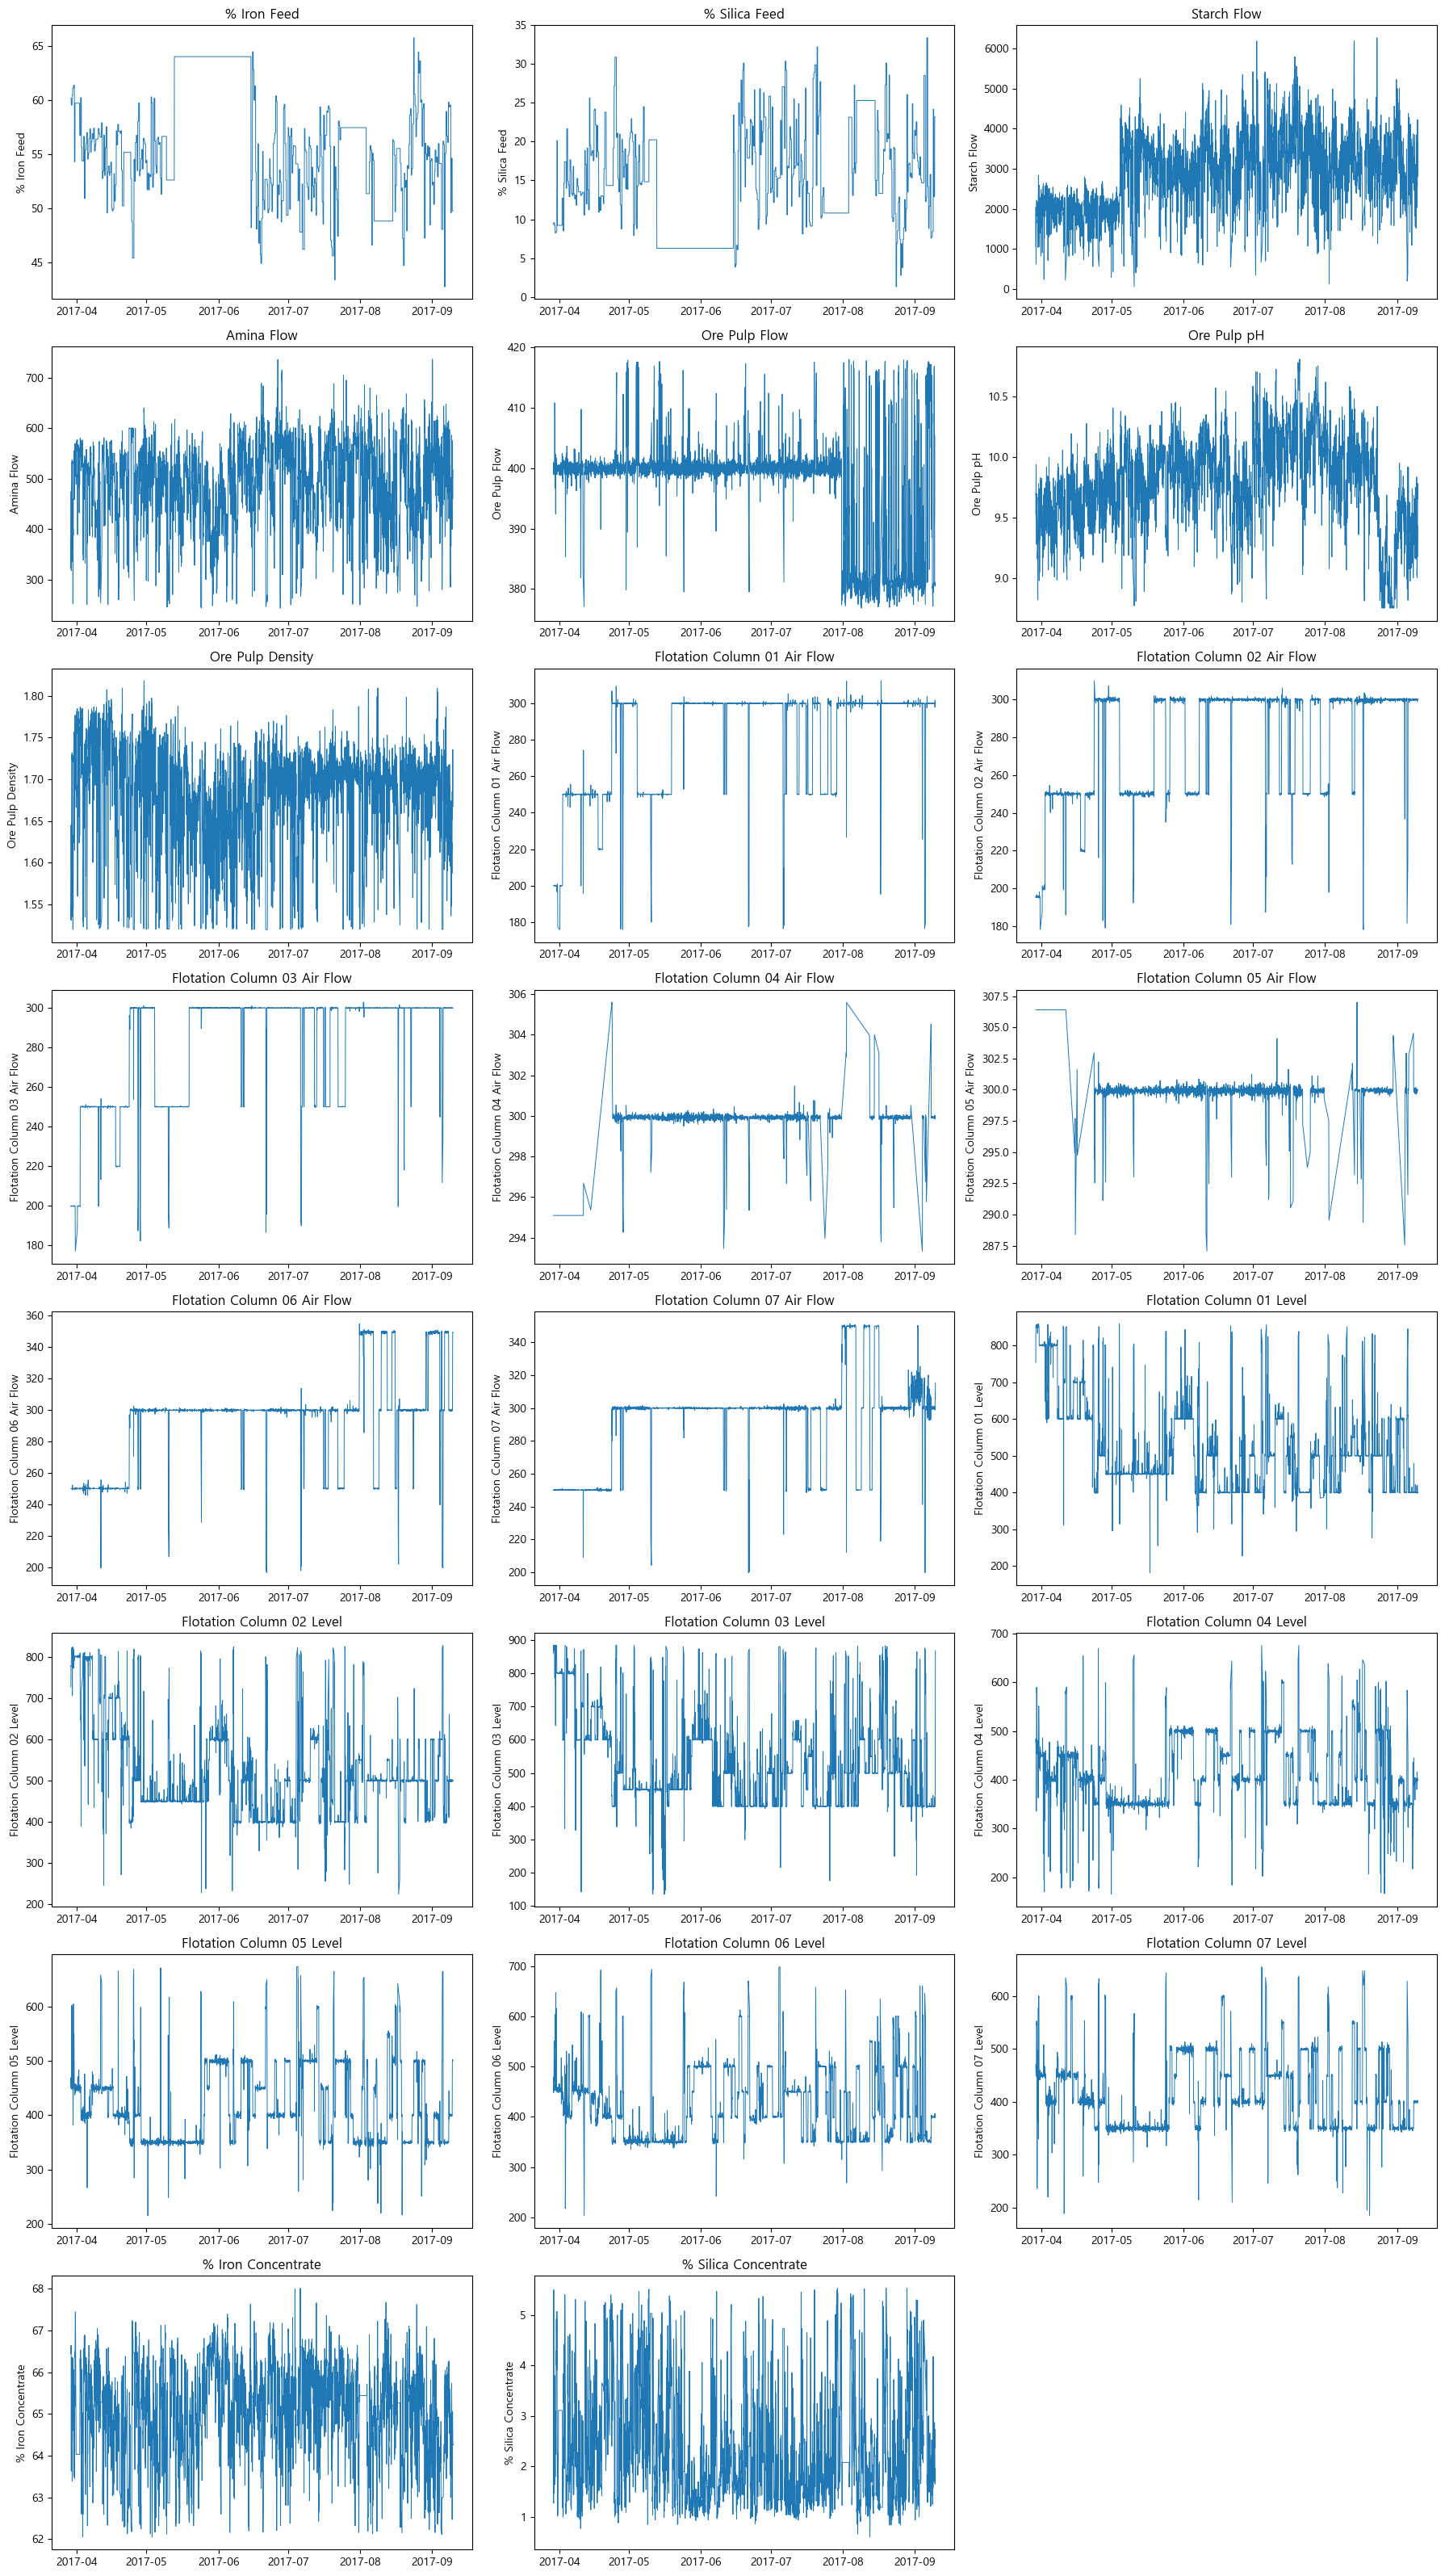

In [10]:
n_cols = 3
n_rows = int(np.ceil(len(num_cols) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    sns.lineplot(data=df_ts, x='date', y=col, ax=axes[i], linewidth=0.7)
    axes[i].set_title(col)
    axes[i].set_xlabel('')
# 남는 빈 subplot 제거
for j in range(len(num_cols), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

In [11]:
# 입력변수(X) / 타겟변수(Y) 분리
Y = df_reg['% Silica Concentrate']
X = df_reg.drop(columns=['% Silica Concentrate'])
print("입력변수 크기 :", X.shape)
print("출력변수 크기 :", Y.shape)
X.head()

입력변수 크기 : (3948, 23)
출력변수 크기 : (3948,)


,date,% Iron Feed,% Silica Feed,Starch Flow,Amina Flow,Ore Pulp Flow,Ore Pulp pH,Ore Pulp Density,Flotation Column 01 Air Flow,Flotation Column 02 Air Flow,...,Flotation Column 06 Air Flow,Flotation Column 07 Air Flow,Flotation Column 01 Level,Flotation Column 02 Level,Flotation Column 03 Level,Flotation Column 04 Level,Flotation Column 05 Level,Flotation Column 06 Level,Flotation Column 07 Level,% Iron Concentrate
0,3/29/2017 12:00,60.18,9.34,1060.859297,379.836203,400.982539,9.527187,1.550374,200.035839,195.577700,...,250.069722,249.992956,753.724247,726.559437,860.557818,477.349197,452.512522,478.219647,470.105547,66.44
1,3/29/2017 13:00,60.18,9.34,2034.926525,322.233975,400.468947,9.700679,1.532017,199.990122,195.106250,...,250.029056,250.059711,848.675503,777.784437,869.419421,483.816131,469.448172,471.607075,462.665478,66.57
2,3/29/2017 14:00,60.18,9.34,1435.425811,474.656322,399.157083,9.687788,1.645200,200.019311,195.604928,...,249.979356,250.111328,851.951492,776.293654,879.704989,456.147231,453.227000,447.708467,453.475667,66.64
3,3/29/2017 15:00,60.18,9.34,618.460387,396.377733,398.942522,9.851689,1.559929,199.940833,195.657094,...,249.978589,250.028506,855.910630,780.369869,882.093896,449.410744,448.581506,450.697578,448.660094,66.41
4,3/29/2017 16:00,59.54,9.56,1367.502858,317.134072,400.836283,9.936163,1.530984,199.878922,196.162864,...,250.061661,250.122067,851.603513,784.446084,884.840698,450.123050,451.774694,451.574422,449.406894,63.63


**[과제]** 써니는 변수들 간에 강하게 얽혀 있는 관계(다중공선성 후보)가 있는지 한눈에 살펴보고 싶습니다. 전체 변수 간 관계를 효율적으로 볼 수 있는 방법을 AI와 상의해서 시각화해 보세요.

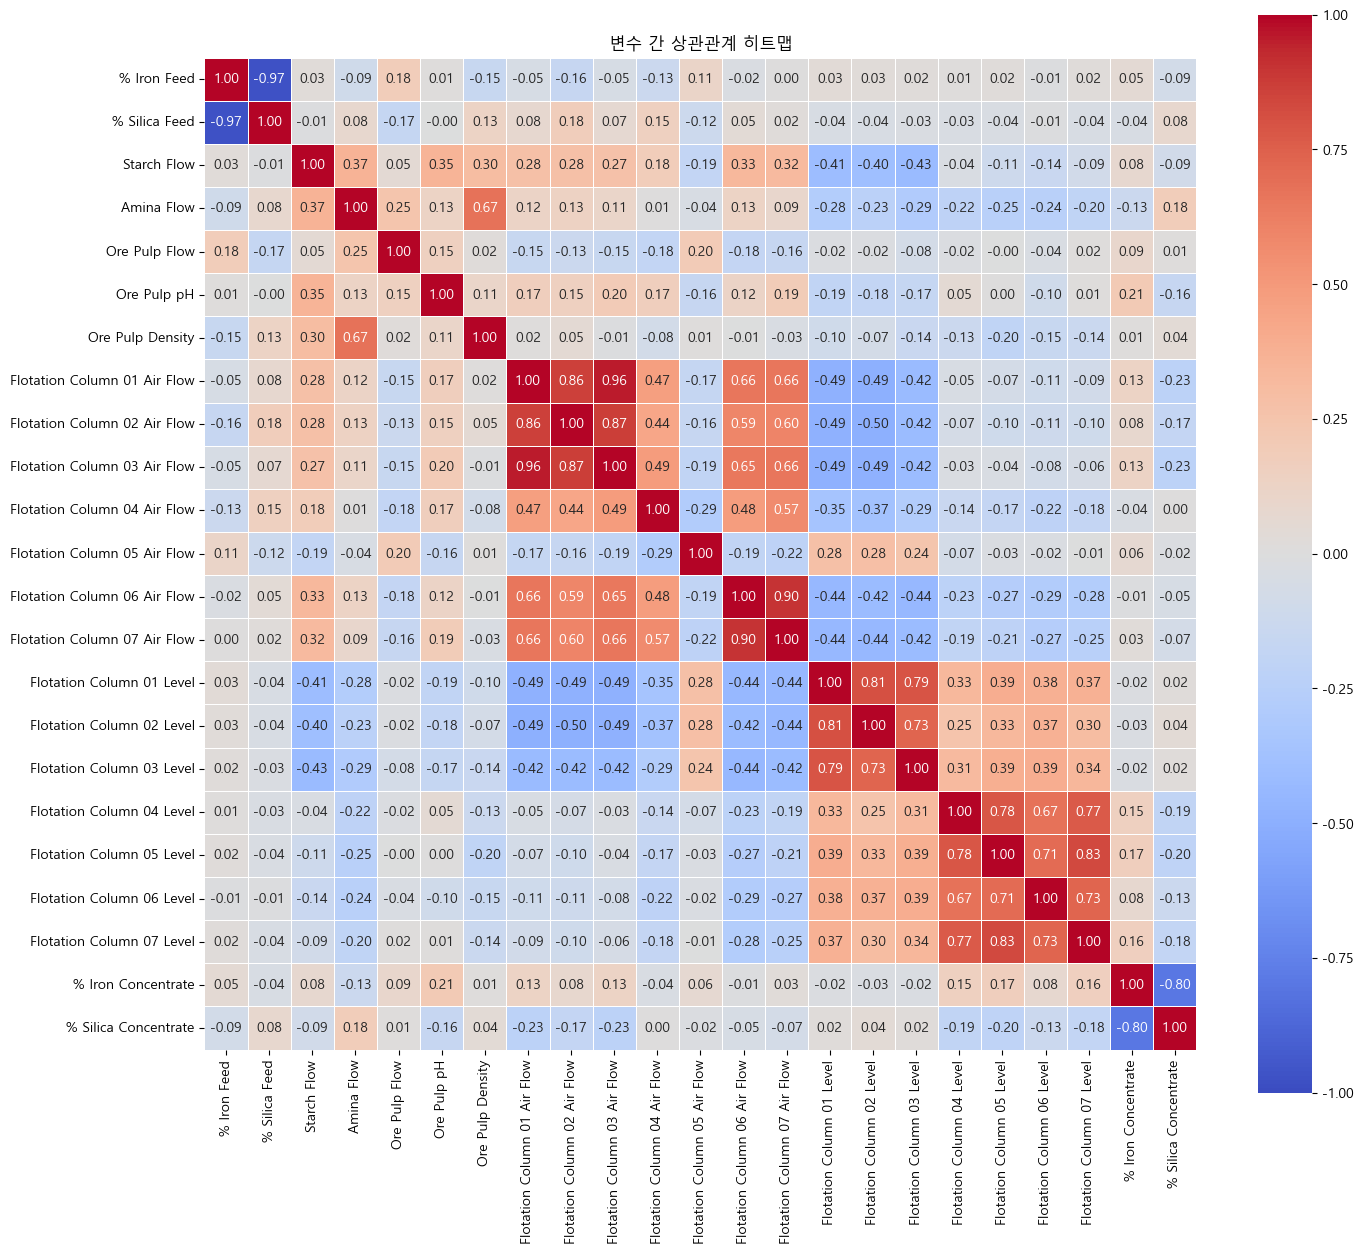

In [12]:
# 1) 수치형 변수만 골라 상관계수 행렬 계산 (date 제외)
corr = df_reg.select_dtypes(include='number').corr()
# 2) 히트맵으로 전체 변수 간 상관관계 시각화
plt.figure(figsize=(16, 14))
sns.heatmap(
    corr,
    annot=True,        # 각 칸에 상관계수 값 표시
    fmt=".2f",         # 소수점 2자리
    cmap="coolwarm",   # 양/음 상관을 색으로 구분
    vmin=-1, vmax=1,   # 색 범위 고정
    square=True,
    linewidths=0.5,
)
plt.title("변수 간 상관관계 히트맵")
plt.show()

In [13]:
# 상관계수 절대값이 높은 변수쌍만 추출 (자기 자신 제외)
corr_pairs = corr.abs().unstack()
corr_pairs = corr_pairs[corr_pairs < 1.0]          # 자기 자신(=1) 제거
corr_pairs = corr_pairs.drop_duplicates().sort_values(ascending=False)
# 상관계수 0.8 이상인 강한 관계쌍만 출력
print(corr_pairs[corr_pairs >= 0.8])

% Iron Feed                   % Silica Feed                   0.972047
Flotation Column 01 Air Flow  Flotation Column 03 Air Flow    0.958320
Flotation Column 06 Air Flow  Flotation Column 07 Air Flow    0.902963
Flotation Column 02 Air Flow  Flotation Column 03 Air Flow    0.874899
Flotation Column 01 Air Flow  Flotation Column 02 Air Flow    0.861870
Flotation Column 05 Level     Flotation Column 07 Level       0.829773
Flotation Column 01 Level     Flotation Column 02 Level       0.807179
% Iron Concentrate            % Silica Concentrate            0.802749
dtype: float64


---
## A-2) 데이터 전처리

### A-2-1) 불필요한 변수 제거 및 결측치 확인

**[과제]** 써니는 모델링 전에 입력변수들을 점검해 보기로 했습니다. AI와 함께 각 변수의 의미를 확인하고, date와 같이 사용 여부를 고민해야 하는 변수나 데이터 누수를 유발할 수 있는 변수가 없는지 검토하고 제거해보세요.

In [14]:
# 제거 대상 변수
#  - date              : 시간 식별자, 입력변수로 부적합
#  - % Iron Concentrate: 타겟과 동시 측정되는 실험실 결과값 → 데이터 누수 위험
drop_cols = ['date', '% Iron Concentrate']
df_reg_clean = df_reg.drop(columns=drop_cols)
print("제거 전 크기 :", df_reg.shape)
print("제거 후 크기 :", df_reg_clean.shape)
df_reg_clean.head()

제거 전 크기 : (3948, 24)
제거 후 크기 : (3948, 22)


,% Iron Feed,% Silica Feed,Starch Flow,Amina Flow,Ore Pulp Flow,Ore Pulp pH,Ore Pulp Density,Flotation Column 01 Air Flow,Flotation Column 02 Air Flow,Flotation Column 03 Air Flow,...,Flotation Column 06 Air Flow,Flotation Column 07 Air Flow,Flotation Column 01 Level,Flotation Column 02 Level,Flotation Column 03 Level,Flotation Column 04 Level,Flotation Column 05 Level,Flotation Column 06 Level,Flotation Column 07 Level,% Silica Concentrate
0,60.18,9.34,1060.859297,379.836203,400.982539,9.527187,1.550374,200.035839,195.577700,199.983717,...,250.069722,249.992956,753.724247,726.559437,860.557818,477.349197,452.512522,478.219647,470.105547,1.36
1,60.18,9.34,2034.926525,322.233975,400.468947,9.700679,1.532017,199.990122,195.106250,199.765344,...,250.029056,250.059711,848.675503,777.784437,869.419421,483.816131,469.448172,471.607075,462.665478,1.43
2,60.18,9.34,1435.425811,474.656322,399.157083,9.687788,1.645200,200.019311,195.604928,199.925800,...,249.979356,250.111328,851.951492,776.293654,879.704989,456.147231,453.227000,447.708467,453.475667,1.33
3,60.18,9.34,618.460387,396.377733,398.942522,9.851689,1.559929,199.940833,195.657094,200.044339,...,249.978589,250.028506,855.910630,780.369869,882.093896,449.410744,448.581506,450.697578,448.660094,1.27
4,59.54,9.56,1367.502858,317.134072,400.836283,9.936163,1.530984,199.878922,196.162864,199.905467,...,250.061661,250.122067,851.603513,784.446084,884.840698,450.123050,451.774694,451.574422,449.406894,5.50


### A-2-2) 입출력 변수 분할 및 데이터 분할

**[과제]** 써니는 `% Silica Concentrate`를 예측하기 위해 입력변수와 타겟 변수를 분리하고자 합니다. 또한 데이터가 시간에 따라 수집되었다는 점을 고려하여 어떤 방식으로 학습 데이터와 테스트 데이터를 나누는 것이 적절할지 AI와 상의한 후, 데이터를 분할해 보세요.

In [15]:
Y = df_reg_clean['% Silica Concentrate']
X = df_reg_clean.drop(columns=['% Silica Concentrate'])
print("입력변수 크기 :", X.shape)
print("출력변수 크기 :", Y.shape)

입력변수 크기 : (3948, 21)
출력변수 크기 : (3948,)


In [16]:
df_reg_ts = df_reg.copy()
df_reg_ts['date'] = pd.to_datetime(df_reg_ts['date'])
df_reg_ts = df_reg_ts.sort_values('date').reset_index(drop=True)
# 누수 변수(% Iron Concentrate)는 시계열 버전에서도 동일하게 제거
df_reg_ts = df_reg_ts.drop(columns=['% Iron Concentrate'])
print("시계열 데이터 크기 :", df_reg_ts.shape)
print("기간 :", df_reg_ts['date'].min(), "~", df_reg_ts['date'].max())
df_reg_ts.head()

시계열 데이터 크기 : (3948, 23)
기간 : 2017-03-29 12:00:00 ~ 2017-09-09 23:00:00


,date,% Iron Feed,% Silica Feed,Starch Flow,Amina Flow,Ore Pulp Flow,Ore Pulp pH,Ore Pulp Density,Flotation Column 01 Air Flow,Flotation Column 02 Air Flow,...,Flotation Column 06 Air Flow,Flotation Column 07 Air Flow,Flotation Column 01 Level,Flotation Column 02 Level,Flotation Column 03 Level,Flotation Column 04 Level,Flotation Column 05 Level,Flotation Column 06 Level,Flotation Column 07 Level,% Silica Concentrate
0,2017-03-29 12:00:00,60.18,9.34,1060.859297,379.836203,400.982539,9.527187,1.550374,200.035839,195.577700,...,250.069722,249.992956,753.724247,726.559437,860.557818,477.349197,452.512522,478.219647,470.105547,1.36
1,2017-03-29 13:00:00,60.18,9.34,2034.926525,322.233975,400.468947,9.700679,1.532017,199.990122,195.106250,...,250.029056,250.059711,848.675503,777.784437,869.419421,483.816131,469.448172,471.607075,462.665478,1.43
2,2017-03-29 14:00:00,60.18,9.34,1435.425811,474.656322,399.157083,9.687788,1.645200,200.019311,195.604928,...,249.979356,250.111328,851.951492,776.293654,879.704989,456.147231,453.227000,447.708467,453.475667,1.33
3,2017-03-29 15:00:00,60.18,9.34,618.460387,396.377733,398.942522,9.851689,1.559929,199.940833,195.657094,...,249.978589,250.028506,855.910630,780.369869,882.093896,449.410744,448.581506,450.697578,448.660094,1.27
4,2017-03-29 16:00:00,59.54,9.56,1367.502858,317.134072,400.836283,9.936163,1.530984,199.878922,196.162864,...,250.061661,250.122067,851.603513,784.446084,884.840698,450.123050,451.774694,451.574422,449.406894,5.50


In [17]:
# 시간 순서 기반 분할 예시 (앞 80% 학습, 뒤 20% 테스트)
split_idx = int(len(df_reg_ts) * 0.8)
train_ts = df_reg_ts.iloc[:split_idx]
test_ts  = df_reg_ts.iloc[split_idx:]
# 입력변수(X) / 타겟(Y) 분리 (date는 입력에서 제외)
feature_cols = df_reg_ts.columns.drop(['date', '% Silica Concentrate'])
X_train = train_ts[feature_cols]
Y_train = train_ts['% Silica Concentrate']
X_test  = test_ts[feature_cols]
Y_test  = test_ts['% Silica Concentrate']
print("학습 기간 :", train_ts['date'].min(), "~", train_ts['date'].max())
print("테스트 기간 :", test_ts['date'].min(), "~", test_ts['date'].max())
print("학습 데이터 크기   :", X_train.shape, Y_train.shape)
print("테스트 데이터 크기 :", X_test.shape, Y_test.shape)

학습 기간 : 2017-03-29 12:00:00 ~ 2017-08-08 01:00:00
테스트 기간 : 2017-08-08 02:00:00 ~ 2017-09-09 23:00:00
학습 데이터 크기   : (3158, 21) (3158,)
테스트 데이터 크기 : (790, 21) (790,)


### A-2-3) 변수 스케일링 및 인코딩

**[과제]** 써니는 변수마다 값의 범위와 단위가 다를 경우 스케일링이 필요하고 범주형 변수의 경우 숫자로 바꿔주는 인코딩이 필요할 수 있다는 것을 배웠습니다. AI와 함께 적절한 스케일링 및 인코딩 기법을 선택하여 적용해 보세요.

In [18]:
from sklearn.model_selection import train_test_split
# 1) X/Y 분리 및 무작위 분할
Yc = df_reg_clean['% Silica Concentrate']
Xc = df_reg_clean.drop(columns=['% Silica Concentrate'])
Xc_train, Xc_test, Yc_train, Yc_test = train_test_split(
    Xc, Yc, test_size=0.2, random_state=42
)
# 2) 수치형/범주형 구분
num_features_c = Xc_train.select_dtypes(include='number').columns.tolist()
cat_features_c = Xc_train.select_dtypes(exclude='number').columns.tolist()
# 3) 스케일링 (학습 데이터로만 fit)
scaler_c = StandardScaler()
Xc_train_scaled = Xc_train.copy()
Xc_test_scaled  = Xc_test.copy()
Xc_train_scaled[num_features_c] = scaler_c.fit_transform(Xc_train[num_features_c])
Xc_test_scaled[num_features_c]  = scaler_c.transform(Xc_test[num_features_c])
# 4) 범주형이 있으면 인코딩
if cat_features_c:
    Xc_train_scaled = pd.get_dummies(Xc_train_scaled, columns=cat_features_c)
    Xc_test_scaled  = pd.get_dummies(Xc_test_scaled, columns=cat_features_c)
    Xc_train_scaled, Xc_test_scaled = Xc_train_scaled.align(
        Xc_test_scaled, join='left', axis=1, fill_value=0
    )
print("스케일링 후 학습 데이터 크기 :", Xc_train_scaled.shape)
Xc_train_scaled.head()

스케일링 후 학습 데이터 크기 : (3158, 21)


,% Iron Feed,% Silica Feed,Starch Flow,Amina Flow,Ore Pulp Flow,Ore Pulp pH,Ore Pulp Density,Flotation Column 01 Air Flow,Flotation Column 02 Air Flow,Flotation Column 03 Air Flow,...,Flotation Column 05 Air Flow,Flotation Column 06 Air Flow,Flotation Column 07 Air Flow,Flotation Column 01 Level,Flotation Column 02 Level,Flotation Column 03 Level,Flotation Column 04 Level,Flotation Column 05 Level,Flotation Column 06 Level,Flotation Column 07 Level
3767,-0.164386,0.398044,-0.560630,0.657018,-1.933193,-1.012600,0.271941,0.626135,0.729498,0.614303,...,-1.850301,1.922573,2.152679,0.167813,-0.169324,-0.939049,-0.177103,-0.316795,-0.861901,-0.947669
1407,1.478040,-1.223798,0.215565,-0.527406,0.202030,0.660432,-0.177155,0.620425,0.721759,0.614915,...,0.098987,0.198228,0.268527,0.680750,0.697433,0.518994,1.107994,1.077457,0.961995,1.160993
2775,0.267131,-0.627872,1.074864,0.460668,0.290530,1.203974,0.366207,-1.098661,-0.980232,-1.172386,...,-1.173133,-1.541772,-1.612391,-0.968257,-1.052063,-0.930802,1.118844,1.096274,1.000577,1.176050
3340,-0.255632,0.035871,0.102826,0.118201,1.469414,0.048262,0.577104,0.619452,0.734591,0.611369,...,0.110561,1.946173,2.149737,-0.148853,-0.183527,-0.214814,1.274173,1.178451,0.854718,1.194304
1116,1.478040,-1.223798,0.900077,-0.634237,0.258096,0.149496,-1.162230,-1.095980,-0.969893,-1.170912,...,0.085479,0.197294,0.270468,-0.553251,-0.618803,-0.618234,-0.749033,-0.932311,-1.015470,-0.854172


In [19]:
# 1) 수치형 / 범주형 변수 자동 구분
num_features = X_train.select_dtypes(include='number').columns.tolist()
cat_features = X_train.select_dtypes(exclude='number').columns.tolist()
print("수치형 변수 :", len(num_features), "개")
print("범주형 변수 :", cat_features if cat_features else "없음")

# 2) 수치형 변수 스케일링 (StandardScaler, 학습 데이터로만 fit)
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled  = X_test.copy()
X_train_scaled[num_features] = scaler.fit_transform(X_train[num_features])
X_test_scaled[num_features]  = scaler.transform(X_test[num_features])
# 3) 범주형 변수가 있을 경우에만 원-핫 인코딩
if cat_features:
    X_train_scaled = pd.get_dummies(X_train_scaled, columns=cat_features)
    X_test_scaled  = pd.get_dummies(X_test_scaled, columns=cat_features)
    # 학습/테스트 컬럼 정렬 맞추기 (한쪽에만 있는 범주 대비)
    X_train_scaled, X_test_scaled = X_train_scaled.align(
        X_test_scaled, join='left', axis=1, fill_value=0
    )
print("스케일링 후 학습 데이터 크기 :", X_train_scaled.shape)
X_train_scaled.head()

수치형 변수 : 21 개
범주형 변수 : 없음
스케일링 후 학습 데이터 크기 : (3158, 21)


,% Iron Feed,% Silica Feed,Starch Flow,Amina Flow,Ore Pulp Flow,Ore Pulp pH,Ore Pulp Density,Flotation Column 01 Air Flow,Flotation Column 02 Air Flow,Flotation Column 03 Air Flow,...,Flotation Column 05 Air Flow,Flotation Column 06 Air Flow,Flotation Column 07 Air Flow,Flotation Column 01 Level,Flotation Column 02 Level,Flotation Column 03 Level,Flotation Column 04 Level,Flotation Column 05 Level,Flotation Column 06 Level,Flotation Column 07 Level
0,0.635935,-0.699104,-1.780479,-1.334504,0.263303,-0.880527,-1.916130,-2.523629,-2.586622,-2.637053,...,2.083594,-1.491997,-1.528020,1.761698,1.592667,2.253049,0.772828,0.374203,0.714697,0.694274
1,0.635935,-0.699104,-0.778146,-2.030641,0.166342,-0.366070,-2.192761,-2.525124,-2.602218,-2.644393,...,2.083594,-1.493559,-1.525420,2.494532,2.004140,2.314311,0.860774,0.609549,0.623222,0.587949
2,0.635935,-0.699104,-1.395043,-0.188579,-0.081324,-0.404299,-0.487207,-2.524170,-2.585721,-2.639000,...,2.083594,-1.495468,-1.523410,2.519816,1.992165,2.385417,0.484497,0.384132,0.292624,0.456618
3,0.635935,-0.699104,-2.235715,-1.134595,-0.121831,0.081719,-1.772152,-2.526736,-2.583995,-2.635015,...,2.083594,-1.495498,-1.526635,2.550372,2.024908,2.401932,0.392886,0.319576,0.333973,0.387799
4,0.512924,-0.666147,-1.464937,-2.092275,0.235691,0.332210,-2.208328,-2.528761,-2.567264,-2.639683,...,2.083594,-1.492307,-1.522992,2.517130,2.057651,2.420921,0.402572,0.363950,0.346103,0.398472


---
## A-3) 모델링

### A-3-1) 다중선형회귀

**[과제]** 써니는 다중선형회귀 모델을 학습시키고, 회귀 계수를 통해 어떤 공정 변수가 실리카 비율에 큰 영향을 주는지 확인하려고 합니다. 모델을 학습하고 회귀 계수를 변수명과 함께 정리해 보세요.

In [20]:
def eval_reg(model, X_tr, Y_tr, X_te, Y_te, name=""):
    model.fit(X_tr, Y_tr)
    pred = model.predict(X_te)
    rmse = np.sqrt(mean_squared_error(Y_te, pred))
    r2 = r2_score(Y_te, pred)
    print(f"[{name}]")
    print(f"  RMSE     : {rmse:.4f}")
    print(f"  R-squared: {r2:.4f}")
    return {"model": name, "RMSE": rmse, "R2": r2, "fitted": model}

In [21]:
# 무작위 분할 (df_reg_clean)
lr_clean = eval_reg(LinearRegression(),
                    Xc_train_scaled, Yc_train, Xc_test_scaled, Yc_test,
                    name="LinearRegression (random split)")
# 시계열 분할 (df_reg_ts)
lr_ts = eval_reg(LinearRegression(),
                 X_train_scaled, Y_train, X_test_scaled, Y_test,
                 name="LinearRegression (time split)")

[LinearRegression (random split)]
  RMSE     : 1.0022
  R-squared: 0.1818
[LinearRegression (time split)]
  RMSE     : 1.1747
  R-squared: -0.0439


In [22]:
# 회귀 계수를 변수명과 함께 정리 (시계열 분할 모델 기준)
coef_lr = pd.DataFrame({
    "변수": X_train_scaled.columns,
    "계수": lr_ts["fitted"].coef_
}).sort_values("계수", key=abs, ascending=False)
print("절편(intercept) :", round(lr_ts["fitted"].intercept_, 4))
coef_lr

절편(intercept) : 2.3215


,변수,계수
3,Amina Flow,0.324455
13,Flotation Column 07 Air Flow,0.320100
12,Flotation Column 06 Air Flow,-0.273800
7,Flotation Column 01 Air Flow,-0.273740
10,Flotation Column 04 Air Flow,0.218745
9,Flotation Column 03 Air Flow,-0.200144
18,Flotation Column 05 Level,-0.171423
6,Ore Pulp Density,-0.155816
2,Starch Flow,-0.101914
1,% Silica Feed,0.097402


### A-3-2) Ridge/Lasso 회귀

**[과제]** 써니는 A-1에서 확인한 다중공선성 문제가 정규화(Regularization) 기법을 통해 완화될 수 있는지 확인해보려고 합니다. Ridge 회귀와 Lasso 회귀 모델을 학습하고 각 모델의 예측 성능과 계수 변화를 함께 분석하여, 해당 데이터에 가장 적절한 모델을 선택하세요.

In [23]:
# 무작위 분할 (df_reg_clean)
ridge_clean = eval_reg(Ridge(alpha=1.0),
                       Xc_train_scaled, Yc_train, Xc_test_scaled, Yc_test,
                       name="Ridge (random split)")
lasso_clean = eval_reg(Lasso(alpha=0.01),
                       Xc_train_scaled, Yc_train, Xc_test_scaled, Yc_test,
                       name="Lasso (random split)")

# 시계열 분할 (df_reg_ts)
ridge_ts = eval_reg(Ridge(alpha=1.0),
                    X_train_scaled, Y_train, X_test_scaled, Y_test,
                    name="Ridge (time split)")
lasso_ts = eval_reg(Lasso(alpha=0.01),
                    X_train_scaled, Y_train, X_test_scaled, Y_test,
                    name="Lasso (time split)")

[Ridge (random split)]
  RMSE     : 1.0022
  R-squared: 0.1818
[Lasso (random split)]
  RMSE     : 1.0024
  R-squared: 0.1815
[Ridge (time split)]
  RMSE     : 1.1730
  R-squared: -0.0410
[Lasso (time split)]
  RMSE     : 1.0947
  R-squared: 0.0933


In [24]:
# 선형/Ridge/Lasso 계수 변화 비교 (시계열 분할 기준)
coef_compare = pd.DataFrame({
    "변수": X_train_scaled.columns,
    "Linear": lr_ts["fitted"].coef_,
    "Ridge": ridge_ts["fitted"].coef_,
    "Lasso": lasso_ts["fitted"].coef_,
}).sort_values("Linear", key=abs, ascending=False)

coef_compare

,변수,Linear,Ridge,Lasso
3,Amina Flow,0.324455,0.323989,0.264520
13,Flotation Column 07 Air Flow,0.320100,0.316192,0.029617
12,Flotation Column 06 Air Flow,-0.273800,-0.269876,-0.000000
7,Flotation Column 01 Air Flow,-0.273740,-0.273571,-0.283736
10,Flotation Column 04 Air Flow,0.218745,0.218613,0.207759
9,Flotation Column 03 Air Flow,-0.200144,-0.199694,-0.117390
18,Flotation Column 05 Level,-0.171423,-0.171233,-0.147771
6,Ore Pulp Density,-0.155816,-0.155568,-0.116301
2,Starch Flow,-0.101914,-0.101792,-0.093102
1,% Silica Feed,0.097402,0.096679,0.049894


### A-3-3) 의사결정나무 회귀

**[과제]** 써니는 공정 변수와 % Silica Concentrate 사이에 선형 회귀만으로는 설명하기 어려운 비선형 관계가 존재할 수 있다고 생각했습니다. AI와 함께 회귀 나무 모델을 구축하고 학습된 트리를 시각화하여 주요 분할 기준과 의사결정 과정을 해석해 보세요.

In [25]:
# 무작위 분할 (df_reg_clean)
dt_clean = eval_reg(DecisionTreeRegressor(max_depth=5, random_state=42),
                    Xc_train_scaled, Yc_train, Xc_test_scaled, Yc_test,
                    name="DecisionTree (random split)")

# 시계열 분할 (df_reg_ts)
dt_ts = eval_reg(DecisionTreeRegressor(max_depth=5, random_state=42),
                 X_train_scaled, Y_train, X_test_scaled, Y_test,
                 name="DecisionTree (time split)")

[DecisionTree (random split)]
  RMSE     : 0.9987
  R-squared: 0.1874
[DecisionTree (time split)]
  RMSE     : 1.1653
  R-squared: -0.0273


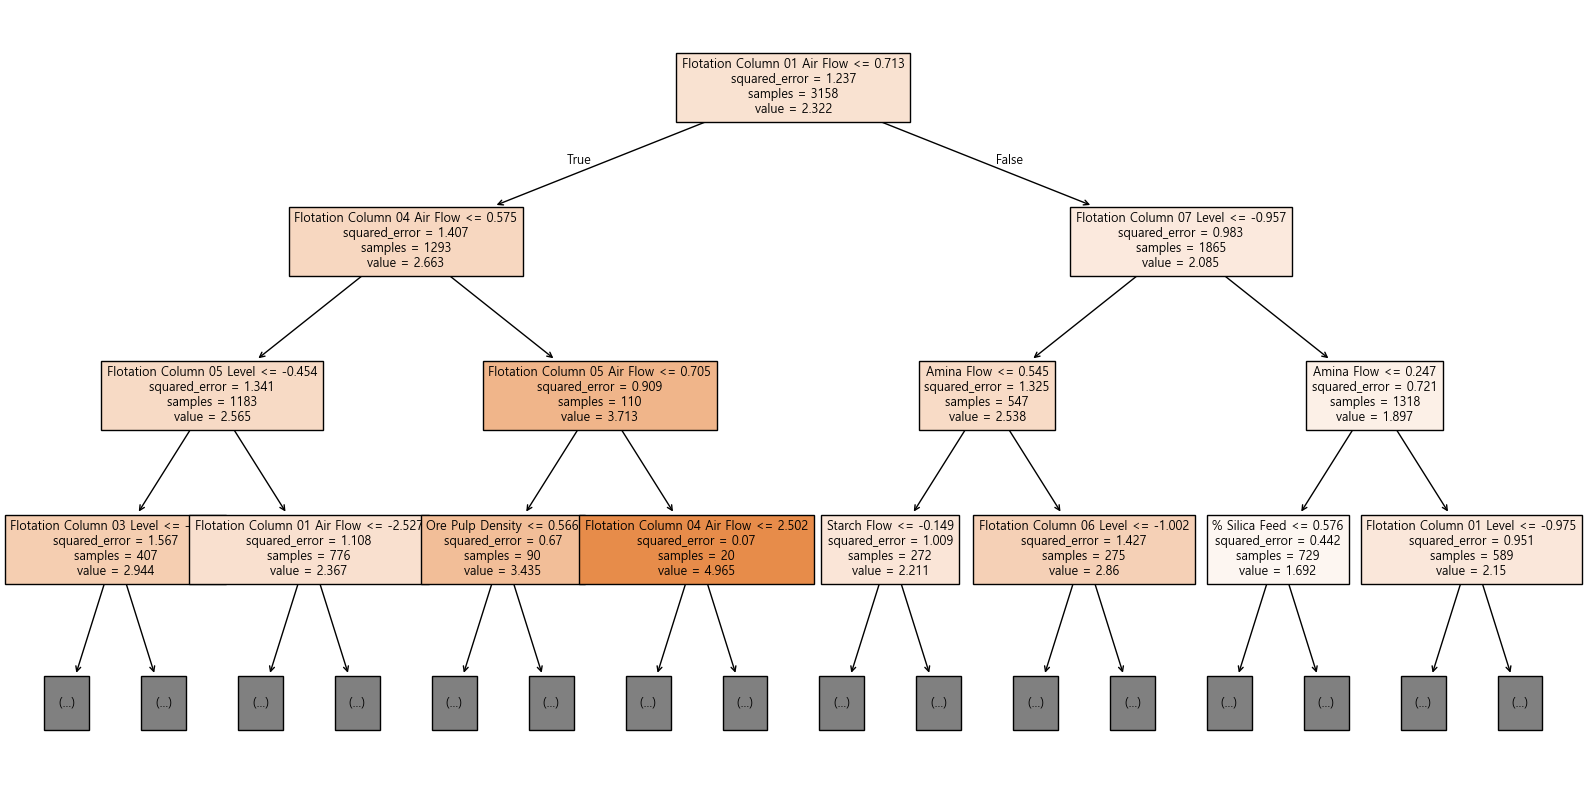

In [26]:
# 학습된 트리 시각화 (시계열 분할 모델, 상위 3단계만 표시)
plt.figure(figsize=(20, 10))
plot_tree(dt_ts["fitted"],
          feature_names=X_train_scaled.columns,
          max_depth=3,
          filled=True,
          fontsize=9)
plt.show()

In [27]:
# 변수 중요도 정리 (시계열 분할 모델 기준)
imp_dt = pd.DataFrame({
    "변수": X_train_scaled.columns,
    "중요도": dt_ts["fitted"].feature_importances_
}).sort_values("중요도", ascending=False)

imp_dt.head(10)

,변수,중요도
7,Flotation Column 01 Air Flow,0.264818
3,Amina Flow,0.132490
20,Flotation Column 07 Level,0.129850
10,Flotation Column 04 Air Flow,0.109130
1,% Silica Feed,0.092178
18,Flotation Column 05 Level,0.072879
6,Ore Pulp Density,0.032827
11,Flotation Column 05 Air Flow,0.031669
2,Starch Flow,0.026987
16,Flotation Column 03 Level,0.025724


---
## A-4) 모델 결과 분석 및 고도화

**[과제]** 써니는 지금까지 만든 회귀 모델들(다중선형회귀, Ridge, Lasso, 의사결정나무)의 성능(RMSE, R-squared 등)을 표나 그래프로 한눈에 비교하고 싶습니다. AI와 상의해서 종합 비교 자료를 만들어 보세요.

In [28]:
# 1) 모든 모델 결과를 하나의 표로 정리
results = [
    lr_clean, ridge_clean, lasso_clean, dt_clean,
    lr_ts, ridge_ts, lasso_ts, dt_ts,
]
result_df = pd.DataFrame([
    {"모델": r["model"], "RMSE": r["RMSE"], "R2": r["R2"]}
    for r in results
])
result_df = result_df.sort_values("RMSE").reset_index(drop=True)
result_df

,모델,RMSE,R2
0,DecisionTree (random split),0.998742,0.187447
1,Ridge (random split),1.002212,0.181791
2,LinearRegression (random split),1.002214,0.181788
3,Lasso (random split),1.002418,0.181453
4,Lasso (time split),1.094748,0.093278
5,DecisionTree (time split),1.165277,-0.027316
6,Ridge (time split),1.173009,-0.040993
7,LinearRegression (time split),1.174656,-0.043919


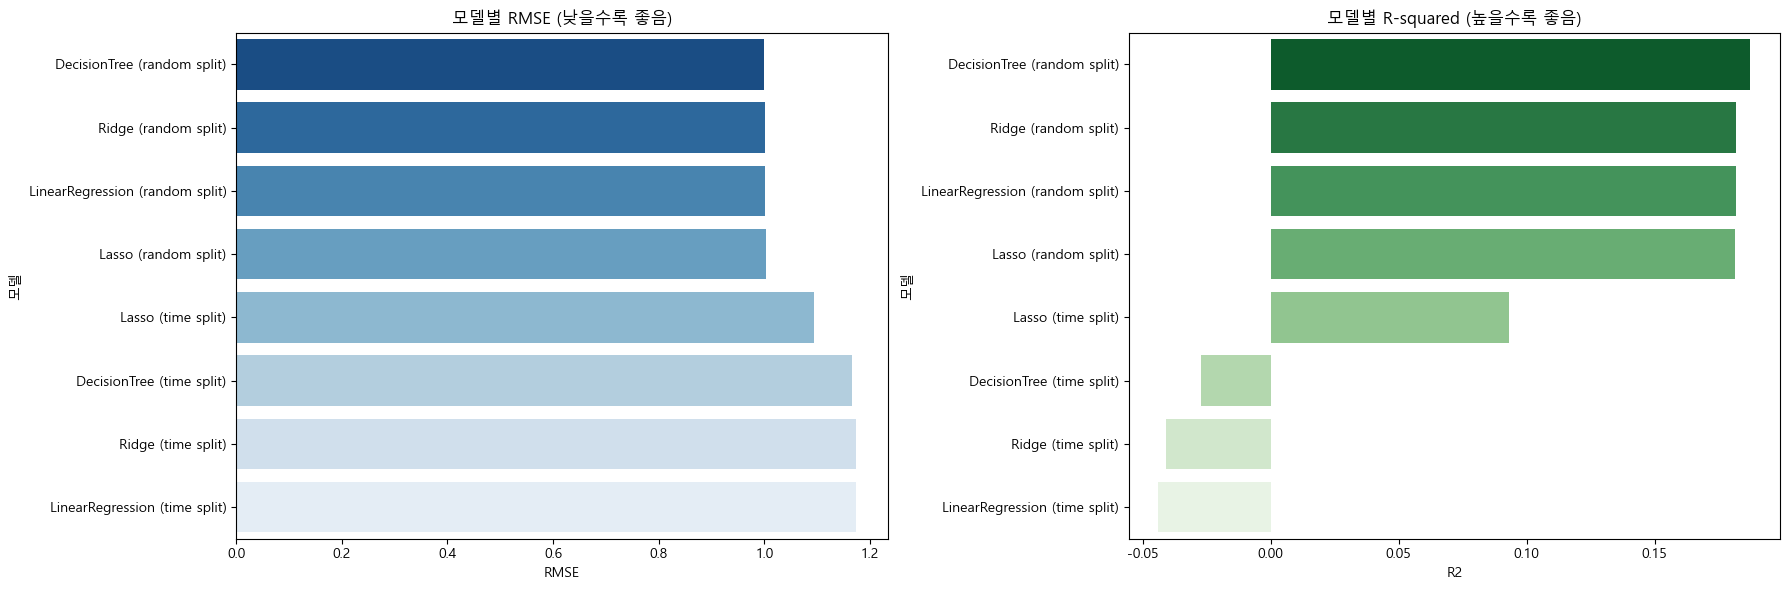

In [29]:
# 2) RMSE / R-squared 비교 그래프 (낮은 RMSE, 높은 R2가 좋음)
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
sns.barplot(data=result_df, y="모델", x="RMSE", ax=axes[0], palette="Blues_r")
axes[0].set_title("모델별 RMSE (낮을수록 좋음)")
sns.barplot(data=result_df, y="모델", x="R2", ax=axes[1], palette="Greens_r")
axes[1].set_title("모델별 R-squared (높을수록 좋음)")
plt.tight_layout()
plt.show()

**[과제]** 써니는 선형 계열 모델의 회귀 계수와 의사결정나무의 변수 중요도를 함께 비교해서, 어떤 공정 변수가 모델 종류와 관계없이 일관되게 중요하게 나타나는지 확인하고 싶습니다. AI와 상의해서 비교 시각화를 만들어 보세요.

In [30]:
features = X_train_scaled.columns
# 선형 계수는 절대값 → 합이 1이 되도록 정규화 (트리 중요도와 척도 통일)
def norm_abs(coef):
    a = np.abs(coef)
    return a / a.sum()
imp_all = pd.DataFrame({
    "변수": features,
    "Linear": norm_abs(lr_ts["fitted"].coef_),
    "Ridge": norm_abs(ridge_ts["fitted"].coef_),
    "Lasso": norm_abs(lasso_ts["fitted"].coef_),
    "DecisionTree": dt_ts["fitted"].feature_importances_,
})
# 네 모델 평균 중요도로 정렬 → 모델 종류와 무관하게 중요한 변수 확인
imp_all["평균중요도"] = imp_all[["Linear", "Ridge", "Lasso", "DecisionTree"]].mean(axis=1)
imp_all = imp_all.sort_values("평균중요도", ascending=False).reset_index(drop=True)
imp_all

,변수,Linear,Ridge,Lasso,DecisionTree,평균중요도
0,Flotation Column 01 Air Flow,0.108279,0.108726,0.200188,0.264818,0.170503
1,Amina Flow,0.128339,0.128763,0.186630,0.132490,0.144056
2,Flotation Column 04 Air Flow,0.086526,0.086884,0.146583,0.109130,0.107281
3,Flotation Column 05 Level,0.067807,0.068054,0.104259,0.072879,0.078250
4,Flotation Column 07 Air Flow,0.126617,0.125664,0.020896,0.018605,0.072945
5,Flotation Column 03 Air Flow,0.079168,0.079365,0.082824,0.008567,0.062481
6,Ore Pulp Density,0.061634,0.061828,0.082055,0.032827,0.059586
7,Flotation Column 06 Air Flow,0.108303,0.107257,0.000000,0.007263,0.055706
8,Flotation Column 07 Level,0.028315,0.028399,0.024483,0.129850,0.052762
9,% Silica Feed,0.038528,0.038423,0.035202,0.092178,0.051083


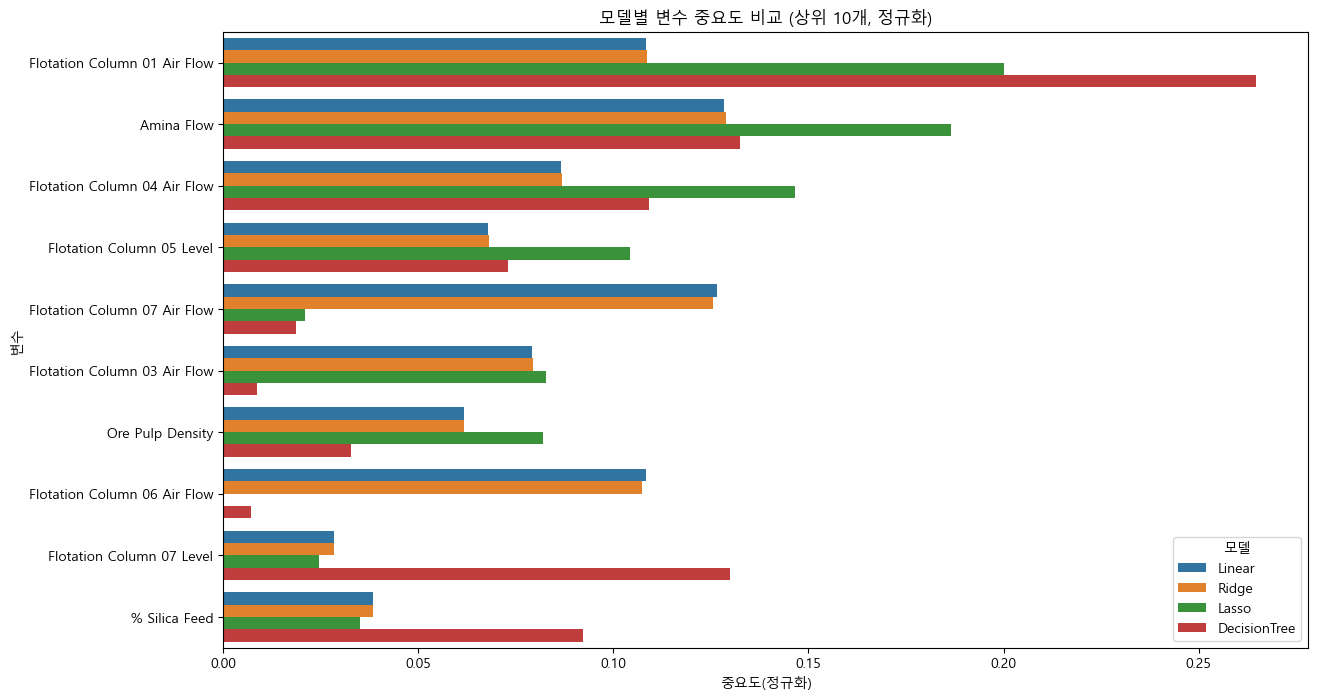

In [31]:
# 1) 상위 10개 변수만 추려서 모델별 중요도 그룹 막대그래프로 비교
top10 = imp_all.head(10)
plot_df = top10.melt(
    id_vars="변수",
    value_vars=["Linear", "Ridge", "Lasso", "DecisionTree"],
    var_name="모델", value_name="중요도(정규화)"
)
plt.figure(figsize=(14, 8))
sns.barplot(data=plot_df, y="변수", x="중요도(정규화)", hue="모델")
plt.title("모델별 변수 중요도 비교 (상위 10개, 정규화)")
plt.legend(title="모델")
plt.show()

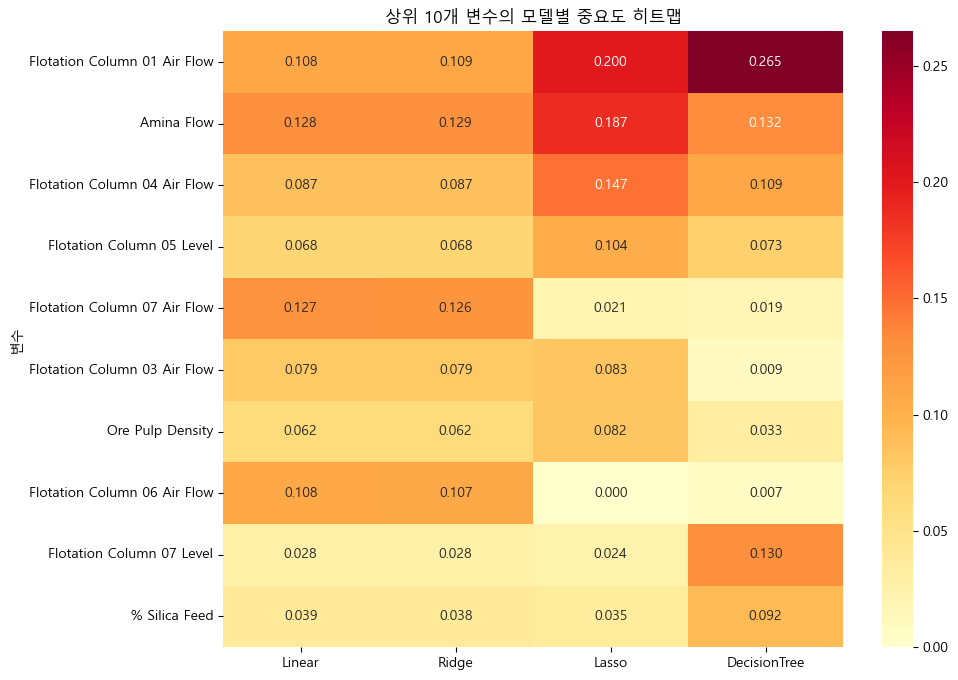

In [32]:
# 2) 히트맵으로 '일관되게 중요한 변수'를 한눈에 확인
plt.figure(figsize=(10, 8))
sns.heatmap(
    top10.set_index("변수")[["Linear", "Ridge", "Lasso", "DecisionTree"]],
    annot=True, fmt=".3f", cmap="YlOrRd"
)
plt.title("상위 10개 변수의 모델별 중요도 히트맵")
plt.show()

**[과제]** 써니는 여러 회귀 모델 중 가장 우수한 모델을 발견했지만, 아직 성능을 더 개선할 여지가 있다고 생각했습니다. AI와 함께 어떤 하이퍼파라미터를 조정해야 할지 논의하고, 적절한 탐색 범위를 설정하여 모델 성능을 최대한 높여보세요.

무작위 모델 성능 업그레이드

In [36]:
# 1) Ridge / Lasso : alpha 탐색 (일반 5-fold 교차검증)
ridge_grid_c = GridSearchCV(
    Ridge(),
    param_grid={"alpha": [0.01, 0.1, 1, 10, 50, 100, 200]},
    scoring="r2", cv=5, n_jobs=-1
)
ridge_grid_c.fit(Xc_train_scaled, Yc_train)

lasso_grid_c = GridSearchCV(
    Lasso(max_iter=10000),
    param_grid={"alpha": [0.0001, 0.001, 0.01, 0.05, 0.1, 0.5]},
    scoring="r2", cv=5, n_jobs=-1
)
lasso_grid_c.fit(Xc_train_scaled, Yc_train)

print("[Ridge] best alpha :", ridge_grid_c.best_params_, "| CV R2 :", round(ridge_grid_c.best_score_, 4))
print("[Lasso] best alpha :", lasso_grid_c.best_params_, "| CV R2 :", round(lasso_grid_c.best_score_, 4))

[Ridge] best alpha : {'alpha': 50} | CV R2 : 0.1855
[Lasso] best alpha : {'alpha': 0.01} | CV R2 : 0.1861


In [37]:
# 2) 의사결정나무 : 깊이/분할 조건 탐색
dt_grid_c = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_grid={
        "max_depth": [5, 10, 15, 20, None],
        "min_samples_split": [2, 10, 50],
        "min_samples_leaf": [1, 5, 20],
    },
    scoring="r2", cv=5, n_jobs=-1
)
dt_grid_c.fit(Xc_train_scaled, Yc_train)

print("[DecisionTree] best params :", dt_grid_c.best_params_)
print("[DecisionTree] best CV R2  :", round(dt_grid_c.best_score_, 4))

[DecisionTree] best params : {'max_depth': 5, 'min_samples_leaf': 5, 'min_samples_split': 2}
[DecisionTree] best CV R2  : 0.1779


In [38]:
# 3) 튜닝된 모델들을 테스트 데이터로 최종 평가 → 기존과 비교
tuned_c = [
    eval_reg(ridge_grid_c.best_estimator_, Xc_train_scaled, Yc_train, Xc_test_scaled, Yc_test, "Ridge (random, tuned)"),
    eval_reg(lasso_grid_c.best_estimator_, Xc_train_scaled, Yc_train, Xc_test_scaled, Yc_test, "Lasso (random, tuned)"),
    eval_reg(dt_grid_c.best_estimator_,    Xc_train_scaled, Yc_train, Xc_test_scaled, Yc_test, "DecisionTree (random, tuned)"),
]

# 튜닝 전(무작위) vs 튜닝 후 비교표
before_c = pd.DataFrame([
    {"모델": r["model"], "RMSE": r["RMSE"], "R2": r["R2"]}
    for r in [ridge_clean, lasso_clean, dt_clean]
])
after_c = pd.DataFrame([
    {"모델": r["model"], "RMSE": r["RMSE"], "R2": r["R2"]}
    for r in tuned_c
])

print("=== 튜닝 전 (무작위 분할) ===")
print(before_c.to_string(index=False))
print("\n=== 튜닝 후 (무작위 분할) ===")
print(after_c.to_string(index=False))

[Ridge (random, tuned)]
  RMSE     : 1.0022
  R-squared: 0.1818
[Lasso (random, tuned)]
  RMSE     : 1.0024
  R-squared: 0.1815
[DecisionTree (random, tuned)]
  RMSE     : 0.9932
  R-squared: 0.1964
=== 튜닝 전 (무작위 분할) ===
                         모델     RMSE       R2
       Ridge (random split) 1.002212 0.181791
       Lasso (random split) 1.002418 0.181453
DecisionTree (random split) 0.998742 0.187447

=== 튜닝 후 (무작위 분할) ===
                          모델     RMSE       R2
       Ridge (random, tuned) 1.002200 0.181810
       Lasso (random, tuned) 1.002418 0.181453
DecisionTree (random, tuned) 0.993203 0.196434


시계열 모델 성능 업그레이드

In [33]:
from sklearn.model_selection import TimeSeriesSplit
# 시계열 순서를 지키는 교차검증 (앞 구간으로 학습 → 다음 구간 검증)
tscv = TimeSeriesSplit(n_splits=5)

# 1) Ridge / Lasso : alpha 탐색
ridge_grid = GridSearchCV(
    Ridge(),
    param_grid={"alpha": [0.01, 0.1, 1, 10, 50, 100, 200]},
    scoring="r2", cv=tscv, n_jobs=-1
)
ridge_grid.fit(X_train_scaled, Y_train)

lasso_grid = GridSearchCV(
    Lasso(max_iter=10000),
    param_grid={"alpha": [0.0001, 0.001, 0.01, 0.05, 0.1, 0.5]},
    scoring="r2", cv=tscv, n_jobs=-1
)
lasso_grid.fit(X_train_scaled, Y_train)

print("[Ridge] best alpha :", ridge_grid.best_params_, "| CV R2 :", round(ridge_grid.best_score_, 4))
print("[Lasso] best alpha :", lasso_grid.best_params_, "| CV R2 :", round(lasso_grid.best_score_, 4))

[Ridge] best alpha : {'alpha': 200} | CV R2 : -0.1538
[Lasso] best alpha : {'alpha': 0.05} | CV R2 : -0.0894


In [34]:
# 2) 의사결정나무 : 깊이/분할 조건 탐색 (가장 개선 여지가 큰 모델)
dt_grid = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_grid={
        "max_depth": [5, 10, 15, 20, None],
        "min_samples_split": [2, 10, 50],
        "min_samples_leaf": [1, 5, 20],
    },
    scoring="r2", cv=tscv, n_jobs=-1
)
dt_grid.fit(X_train_scaled, Y_train)

print("[DecisionTree] best params :", dt_grid.best_params_)
print("[DecisionTree] best CV R2  :", round(dt_grid.best_score_, 4))

[DecisionTree] best params : {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 10}
[DecisionTree] best CV R2  : -0.4422


In [39]:
# 3) 튜닝된 모델들을 테스트 데이터로 최종 평가 → 기존과 비교
tuned = [
    eval_reg(ridge_grid.best_estimator_, X_train_scaled, Y_train, X_test_scaled, Y_test, "Ridge (tuned)"),
    eval_reg(lasso_grid.best_estimator_, X_train_scaled, Y_train, X_test_scaled, Y_test, "Lasso (tuned)"),
    eval_reg(dt_grid.best_estimator_,   X_train_scaled, Y_train, X_test_scaled, Y_test, "DecisionTree (tuned)"),
]

# 튜닝 전(시계열) vs 튜닝 후 비교표
before = pd.DataFrame([
    {"모델": r["model"], "RMSE": r["RMSE"], "R2": r["R2"]}
    for r in [ridge_ts, lasso_ts, dt_ts]
])
after = pd.DataFrame([
    {"모델": r["model"], "RMSE": r["RMSE"], "R2": r["R2"]}
    for r in tuned
])

print("=== 튜닝 전 ===")
print(before.to_string(index=False))
print("\n=== 튜닝 후 ===")
print(after.to_string(index=False))

[Ridge (tuned)]
  RMSE     : 1.1008
  R-squared: 0.0833
[Lasso (tuned)]
  RMSE     : 1.1147
  R-squared: 0.0600
[DecisionTree (tuned)]
  RMSE     : 1.1653
  R-squared: -0.0273
=== 튜닝 전 ===
                       모델     RMSE        R2
       Ridge (time split) 1.173009 -0.040993
       Lasso (time split) 1.094748  0.093278
DecisionTree (time split) 1.165277 -0.027316

=== 튜닝 후 ===
                  모델     RMSE        R2
       Ridge (tuned) 1.100767  0.083281
       Lasso (tuned) 1.114681  0.059959
DecisionTree (tuned) 1.165277 -0.027316


In [ ]:
# ===== A-4 고도화: 낮은 R^2 원인 진단 & 최적 회귀 모델 =====
# [원인 진단]
#  1) 공정변수 -> % Silica Concentrate 관계가 '비선형 + 변수 간 상호작용' 중심.
#     선형계열(Linear/Ridge/Lasso)과 얕은 단일 트리는 이를 못 담아 과소적합 -> R^2 낮음.
#  2) Flotation Column 01~07 등 유사 변수의 다중공선성으로 선형모델 계수가 불안정.
#  => 결론: 비선형/상호작용/다중공선성에 강건한 앙상블(RandomForest)이 최적.
#     (배운 의사결정나무를 여러 개 묶은 확장 모델, 스케일링 불필요)

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# --- 데이터 로드 & 전처리 (단독 실행 가능) ---
df = pd.read_csv('dataset/day2_miniproject_reg.csv')
df = df.drop(columns=['date', '% Iron Concentrate'])   # 식별자 / 누수 변수 제거
y = df['% Silica Concentrate']
X = df.drop(columns=['% Silica Concentrate'])

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_tr)
X_te_s = scaler.transform(X_te)

# --- 모델별 성능 비교 (원인 확인용) ---
models = {
    'LinearRegression': LinearRegression(),
    'DecisionTree (depth=5)': DecisionTreeRegressor(max_depth=5, random_state=42),
    'RandomForest': RandomForestRegressor(n_estimators=300, min_samples_leaf=2,
                                          n_jobs=-1, random_state=42),
}
rows = []
for name, m in models.items():
    m.fit(X_tr_s, y_tr)
    p = m.predict(X_te_s)
    rows.append({'모델': name,
                 'RMSE': round(np.sqrt(mean_squared_error(y_te, p)), 4),
                 'R2': round(r2_score(y_te, p), 4)})
compare = pd.DataFrame(rows)
print(compare.to_string(index=False))

# --- 최적 모델(RandomForest) 변수 중요도 ---
best = models['RandomForest']
imp = pd.DataFrame({'변수': X.columns, '중요도': best.feature_importances_}) \
        .sort_values('중요도', ascending=False).reset_index(drop=True)
imp.head(10)

---
# Part B. 분류 태스크 — Steel Plates Faults

## B-0) 데이터 불러오기

**[과제]** 써니는 `dataset/day2_miniproject_cls.csv` 파일을 불러오려고 합니다. 적절한 변수명으로 데이터프레임을 만들어 보세요.

In [ ]:
# Part B 라이브러리 (Part A 실행 여부와 무관하게 단독 실행 가능하도록 포함)
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
)

# 한글 폰트 설정 (Windows)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

import warnings
warnings.filterwarnings('ignore')

# 분류용 데이터 불러오기
df_cls = pd.read_csv('dataset/day2_miniproject_cls.csv')

print("데이터 크기 :", df_cls.shape)
df_cls.head()

---
## B-1) 데이터 탐색 (EDA)

**[과제]** 써니는 타겟 변수의 분포가 어떻게 구성되어 있는지 궁금해졌습니다. AI와 함께 적절한 시각화 기법을 선택하여 타겟 변수의 빈도와 비율을 분석하고, 분석 결과를 바탕으로 향후 모델링 과정에서 고려해야 할 사항이 무엇인지 생각해 보세요.

In [ ]:
# 타겟 변수(K_Scatch) 분포 확인
target = 'K_Scatch'

print("빈도 :")
print(df_cls[target].value_counts())
print("\n비율 :")
print(df_cls[target].value_counts(normalize=True).round(3))

# 타겟 분포 시각화
plt.figure(figsize=(6, 4))
sns.countplot(data=df_cls, x=target)
plt.title('K_Scatch 타겟 분포 (0 = 아님 / 1 = 스크래치 결함)')
plt.xlabel('K_Scatch')
plt.ylabel('개수')
plt.show()

---
## B-2) 데이터 전처리

### B-2-1) 타겟 변수 정의

**[과제]** 써니는 K_Scratch를 분류 타겟(0/1)으로 사용하기로 했습니다. 이때 나머지 결함 유형 컬럼(Pastry, Z_Scratch, Stains, Dirtiness, Bumps, Other_Faults)이 타겟과 어떤 관계를 가지는지 궁금해졌습니다. AI와 함께 각 변수의 의미와 타겟과의 관계를 분석하고, 모델링 과정에서 해당 변수들을 사용하는 것이 적절한지 판단한 뒤 필요한 전처리를 수행해 보세요.

In [ ]:
# 결함 유형 컬럼 (K_Scatch 포함) — 서로 배타적인 다중 클래스 원-핫 라벨
fault_cols = ['Pastry', 'Z_Scratch', 'K_Scatch', 'Stains', 'Dirtiness', 'Bumps', 'Other_Faults']

# 각 행이 하나의 결함 유형에만 속하는지(배타성) 확인
print("한 행당 결함 라벨 개수 분포 :")
print(df_cls[fault_cols].sum(axis=1).value_counts())

# 타겟 정의 : K_Scatch (0/1)
y = df_cls['K_Scatch'].astype(int)

# 나머지 결함 유형 컬럼은 타겟과 배타적 관계 → 알면 정답이 노출됨(데이터 누수) → 제거
leak_cols = ['Pastry', 'Z_Scratch', 'Stains', 'Dirtiness', 'Bumps', 'Other_Faults']
X = df_cls.drop(columns=['K_Scatch'] + leak_cols)

print("\n입력변수 크기 :", X.shape)
print("입력변수 목록 :")
print(X.columns.tolist())

### B-2-2) 결측치 확인 및 데이터 분할

**[과제]** 써니는 결측치를 확인한 후 모델링을 위한 데이터를 준비하고자 합니다. AI와 함께 변수별 특성을 고려하여 적절한 결측치 처리 방법을 적용하고, 분류 모델 학습에 적합한 방식으로 학습 데이터와 테스트 데이터를 분할해 보세요.

In [ ]:
# 결측치 확인
print("변수별 결측치 (상위) :")
print(X.isnull().sum().sort_values(ascending=False).head())
print("\n총 결측치 개수 :", X.isnull().sum().sum())

# 층화 분할(stratify) — 클래스 불균형이 있으므로 학습/테스트의 타겟 비율을 동일하게 유지
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("\n학습 데이터 크기   :", X_train.shape)
print("테스트 데이터 크기 :", X_test.shape)
print("\n학습 타겟 비율 :")
print(y_train.value_counts(normalize=True).round(3))
print("테스트 타겟 비율 :")
print(y_test.value_counts(normalize=True).round(3))

### B-2-3) 변수 스케일링

**[과제]** 써니는 데이터셋에 수치형 변수와 범주형 변수가 함께 존재한다는 점을 확인했습니다. AI와 함께 각 변수의 특성과 분포를 살펴보고, 스케일링이 필요한 변수를 판단한 뒤 적절한 스케일링 기법을 선택하여 적용해 보세요.

In [ ]:
# 수치형 / 이진(범주형 지시) 변수 구분
# TypeOfSteel_A300, TypeOfSteel_A400은 0/1 지시변수이므로 스케일링 제외
binary_cols = ['TypeOfSteel_A300', 'TypeOfSteel_A400']
num_cols = [c for c in X_train.columns if c not in binary_cols]

# 수치형 변수만 표준화 (학습 데이터로만 fit → 테스트는 transform)
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test_scaled[num_cols] = scaler.transform(X_test[num_cols])

print("스케일링 완료 — 수치형", len(num_cols), "개 / 이진 지시변수", len(binary_cols), "개")
X_train_scaled.head()

---
## B-3) 모델링

### B-3-1) 로지스틱 회귀

**[과제]** 써니는 로지스틱 회귀 모델을 학습시키고, 회귀 계수를 통해 어떤 변수가 K_Scatch 여부에 큰 영향을 주는지 확인하려고 합니다. 모델을 학습하고 회귀 계수의 절대값 기준으로 변수 영향력을 정리해 보세요.

In [ ]:
# 로지스틱 회귀 학습
logit = LogisticRegression(max_iter=1000)
logit.fit(X_train_scaled, y_train)

# 회귀 계수를 절대값(영향력) 기준으로 정리
coef_logit = pd.DataFrame({
    '변수': X_train_scaled.columns,
    '계수': logit.coef_[0],
})
coef_logit['영향력(절대값)'] = coef_logit['계수'].abs()
coef_logit = coef_logit.sort_values('영향력(절대값)', ascending=False).reset_index(drop=True)

print("절편(intercept) :", round(logit.intercept_[0], 4))
coef_logit

### B-3-2) 의사결정나무 분류

**[과제]** 써니는 의사결정나무를 활용해 K_Scratch가 어떤 변수와 기준값에 의해 분류되는지 직관적으로 이해하고자 합니다. AI와 함께 분류 나무 모델을 구축하고 학습된 트리를 시각화하여 주요 분할 기준과 의사결정 과정을 해석해 보세요.

In [ ]:
# 의사결정나무 분류 학습
dtree = DecisionTreeClassifier(max_depth=5, random_state=42)
dtree.fit(X_train_scaled, y_train)

# 학습된 트리 시각화 (상위 3단계만 표시)
plt.figure(figsize=(20, 10))
plot_tree(
    dtree,
    feature_names=X_train_scaled.columns,
    class_names=['Not K_Scatch', 'K_Scatch'],
    max_depth=3,
    filled=True,
    fontsize=9,
)
plt.title('의사결정나무 분류 (상위 3단계)')
plt.show()

# 변수 중요도 정리
imp_dtree = pd.DataFrame({
    '변수': X_train_scaled.columns,
    '중요도': dtree.feature_importances_,
}).sort_values('중요도', ascending=False).reset_index(drop=True)
imp_dtree.head(10)

---
## B-4) 테스트 데이터 예측

**[과제]** 써니는 로지스틱 회귀와 의사결정나무 분류 모델로 테스트 데이터에 대한 예측을 수행하고, Accuracy·Precision·Recall·F1-score와 혼동행렬을 함께 비교하려고 합니다. AI와 상의해서 두 모델의 예측과 성능 지표를 한 번에 뽑을 수 있도록 코드를 작성해 보세요.

In [ ]:
# 두 모델의 예측 성능을 한 번에 계산하는 함수
def eval_cls(model, name):
    pred = model.predict(X_test_scaled)
    print(f"[{name}]")
    print(f"  Accuracy : {accuracy_score(y_test, pred):.4f}")
    print(f"  Precision: {precision_score(y_test, pred):.4f}")
    print(f"  Recall   : {recall_score(y_test, pred):.4f}")
    print(f"  F1-score : {f1_score(y_test, pred):.4f}")
    print()
    return pred

pred_logit = eval_cls(logit, 'LogisticRegression')
pred_dtree = eval_cls(dtree, 'DecisionTree')

# 혼동행렬 비교 시각화
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, pred, name in zip(axes, [pred_logit, pred_dtree],
                          ['LogisticRegression', 'DecisionTree']):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Not K', 'K'], yticklabels=['Not K', 'K'])
    ax.set_title(f'{name} 혼동행렬')
    ax.set_xlabel('예측')
    ax.set_ylabel('실제')
plt.tight_layout()
plt.show()

---
## B-5) 모델 고도화

**[과제]** 써니는 분류 모델링 결과를 살펴보며 클래스 불균형이 모델 성능에 영향을 줄 수 있다고 생각했습니다. AI와 함께 이를 해결할 수 있는 로지스틱 회귀와 분류 나무 각각에 적합한 하이퍼파라미터와 튜닝 방법을 탐색하고, 최적의 파라미터를 찾아 모델을 다시 학습해 보세요. 이후 성능이 얼마나 개선되었는지 비교해 보세요.

In [ ]:
# 클래스 불균형 대응 : class_weight='balanced' + GridSearchCV (F1 기준 튜닝)
# 1) 로지스틱 회귀 튜닝
logit_grid = GridSearchCV(
    LogisticRegression(max_iter=1000, class_weight='balanced'),
    param_grid={'C': [0.01, 0.1, 1, 10, 100]},
    scoring='f1', cv=5, n_jobs=-1,
)
logit_grid.fit(X_train_scaled, y_train)

# 2) 의사결정나무 튜닝
dtree_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42, class_weight='balanced'),
    param_grid={
        'max_depth': [3, 5, 10, 15, None],
        'min_samples_leaf': [1, 5, 20],
        'min_samples_split': [2, 10, 50],
    },
    scoring='f1', cv=5, n_jobs=-1,
)
dtree_grid.fit(X_train_scaled, y_train)

print("[Logit] best params :", logit_grid.best_params_, "| CV F1 :", round(logit_grid.best_score_, 4))
print("[Tree ] best params :", dtree_grid.best_params_, "| CV F1 :", round(dtree_grid.best_score_, 4))

# 튜닝 전/후 성능 비교표 (F1 중심)
def metrics_row(model, name):
    pred = model.predict(X_test_scaled)
    return {
        '모델': name,
        'Accuracy': round(accuracy_score(y_test, pred), 4),
        'Precision': round(precision_score(y_test, pred), 4),
        'Recall': round(recall_score(y_test, pred), 4),
        'F1': round(f1_score(y_test, pred), 4),
    }

compare_df = pd.DataFrame([
    metrics_row(logit, 'Logit (기본)'),
    metrics_row(logit_grid.best_estimator_, 'Logit (튜닝)'),
    metrics_row(dtree, 'Tree (기본)'),
    metrics_row(dtree_grid.best_estimator_, 'Tree (튜닝)'),
])
compare_df